
                                          LInear Regression On Insurance data set


Implement ml model on insurance data and predict insurance charges

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df1=pd.read_csv("insurance.xls")
df1

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In this target variable is labelled as 'charges' so we can apply supervised learning

In [ ]:
# understanding data or future engineering

In [3]:
df1.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [4]:
df1.ndim

2

In [5]:
df1.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='str')

In [6]:
df1.shape

(1338, 13)

In [7]:
df1.size

17394

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   str    
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   str    
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   str    
 12  charges                        

In [9]:
df1.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [10]:
# Replace the null value by mode for string and mean or median for the numeric
df1=df1.dropna()
   

        
    

In [11]:
df1.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [12]:
df1.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1287.000000,1287.000000,1287.000000,1287.000000,1287.000000,1.287000e+03,1.287000e+03,1287.000000,1.287000e+03,1287.000000
mean,39.419580,30.655746,1.094794,33498.578933,15.247086,9.113778e+05,1.579929e+07,1.068376,3.727972e+08,13366.072420
std,14.051987,6.086323,1.202782,15611.720348,7.457366,9.083364e+04,2.653821e+07,0.529079,5.655770e+08,12025.821700
min,18.000000,15.960000,0.000000,2912.590584,1.000000,6.991570e+05,2.945253e+04,0.000000,3.150786e+06,1121.873900
25%,27.000000,26.220000,0.000000,20905.974820,9.000000,8.489270e+05,4.114357e+06,1.000000,7.964523e+07,4842.251225
50%,40.000000,30.360000,1.000000,33968.774160,15.000000,9.152840e+05,7.567064e+06,1.000000,1.451129e+08,9549.565100
75%,51.000000,34.600000,2.000000,45152.414195,20.000000,9.726140e+05,1.093014e+07,1.000000,3.337660e+08,16964.132700
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [13]:
# check the duplicate values
df1.duplicated().sum()

np.int64(0)

Exploratory data Anaylsis(EDA)

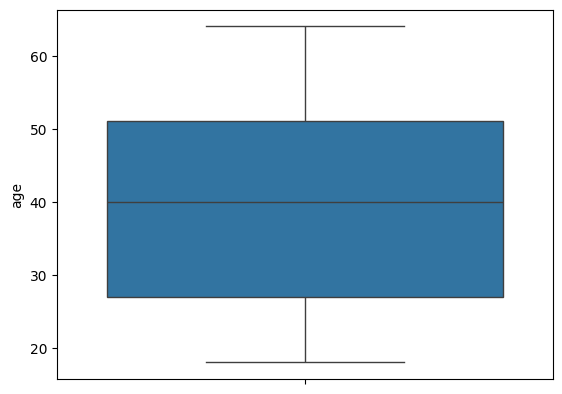

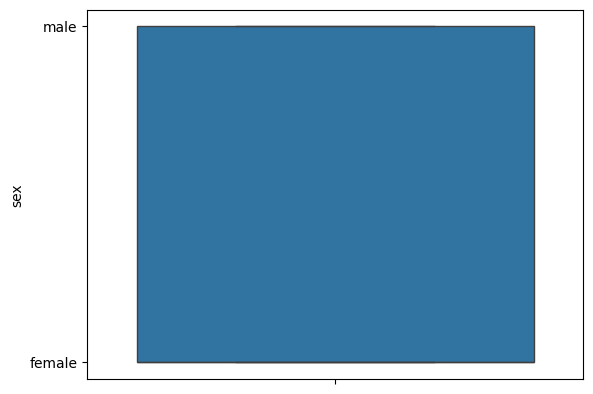

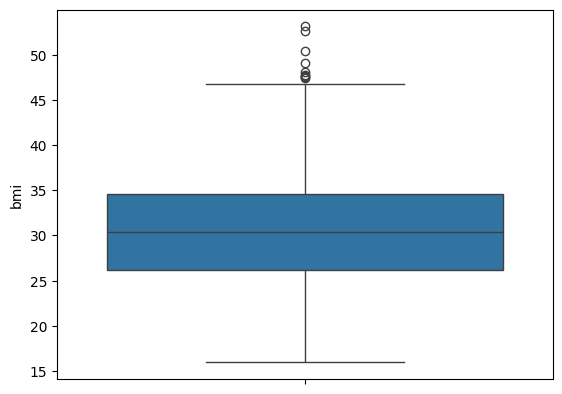

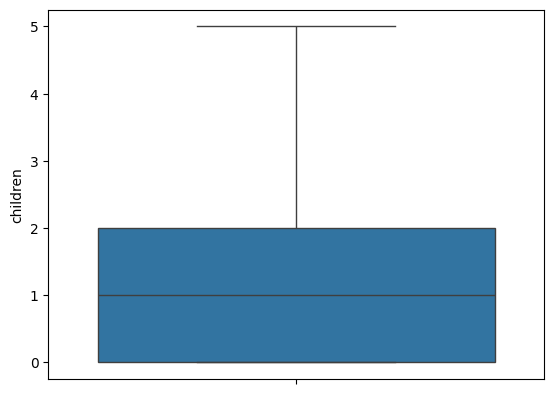

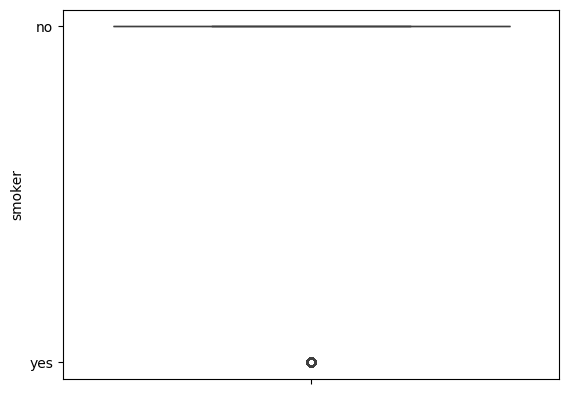

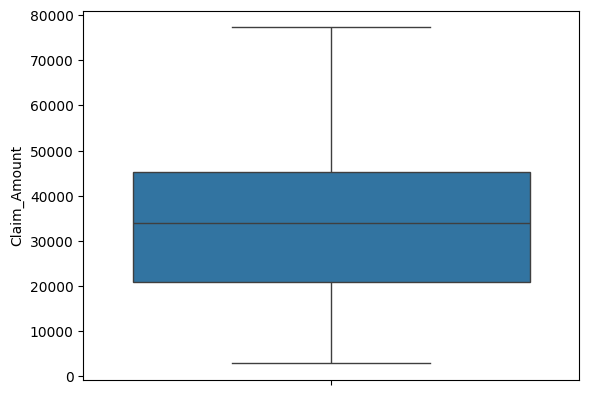

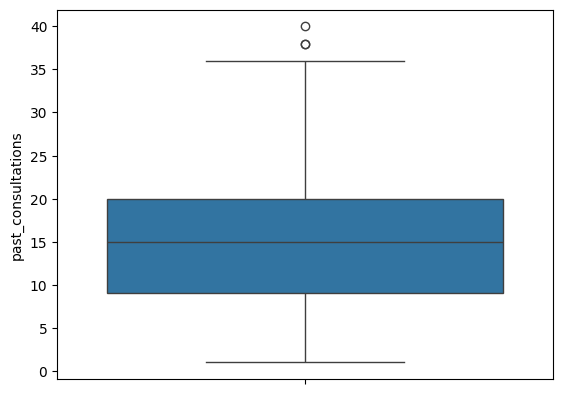

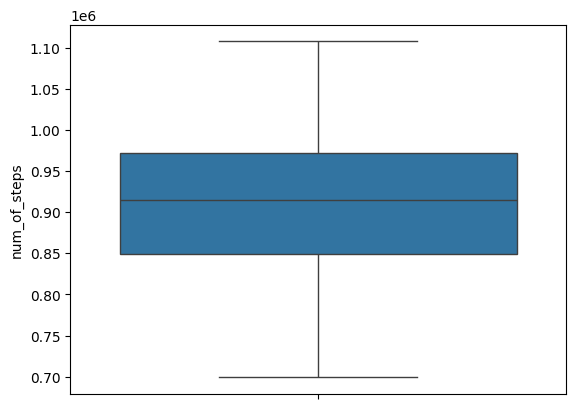

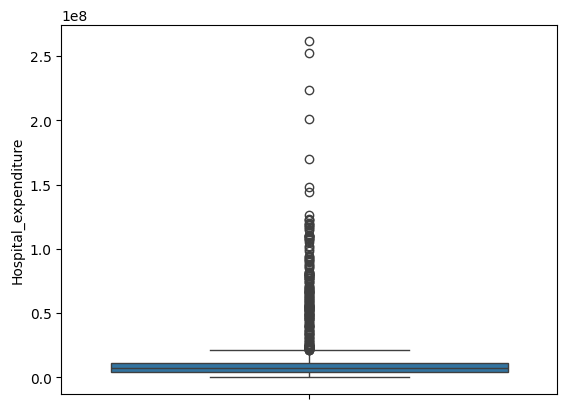

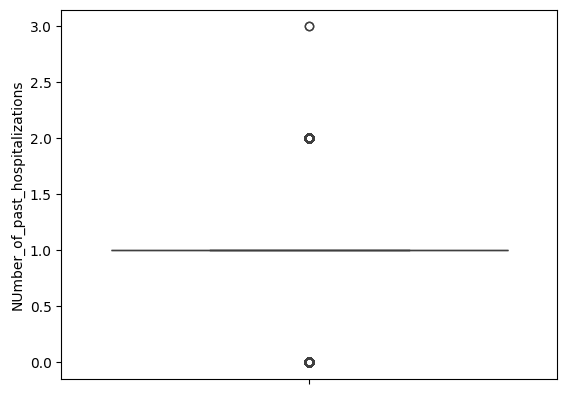

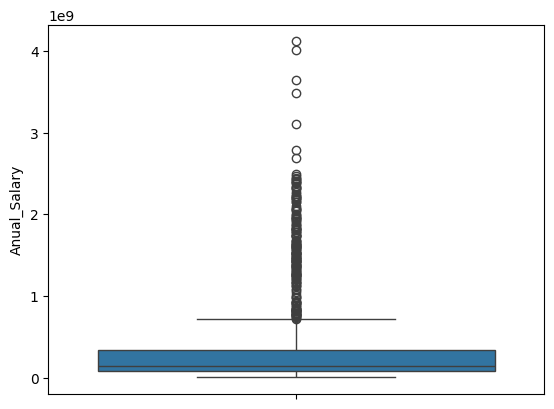

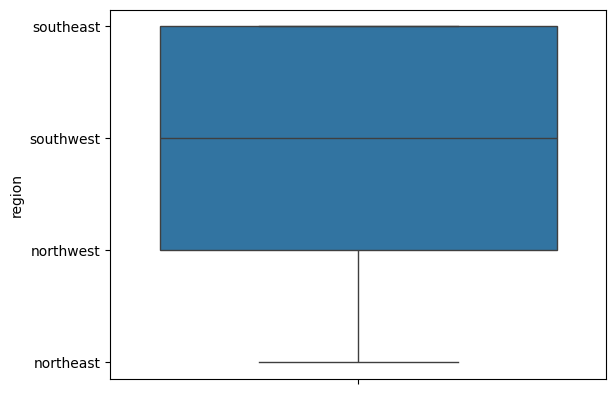

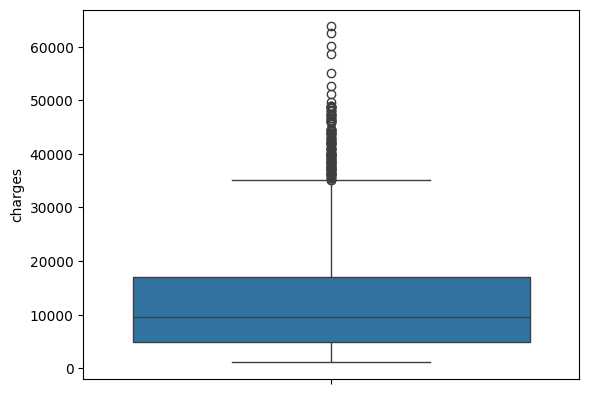

In [14]:
# checking outliers using box plot
for i in df1.columns:
    if(df1[i].dtype!='object'):
        sns.boxplot(df1[i])
        plt.show()

In [15]:
df1.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='str')

In [16]:
out_cols=['bmi','past_consultations','Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary',  'charges']
for i in out_cols:
    q1=df1[i].quantile(0.25)
    q3=df1[i].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    df1=df1[(df1[i]>=lb) &(df1[i]<=ub)]


Encoding :converting object columns to numeric columns

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
for col in df1.columns:
    if(df1[col].dtype=='object'):
        df1[col]=encoder.fit_transform(df1[col])


In [21]:
df1.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,male,27.550,0.0,no,39148.95495,10.0,780652.0,8.614147e+06,1.0,54526009.33,northwest,2523.16950
152,22.0,female,20.235,0.0,no,41547.52536,13.0,802627.0,2.491594e+05,1.0,16718473.13,northwest,2527.81865
153,25.0,male,35.625,0.0,no,39660.60193,12.0,770773.0,3.043323e+06,1.0,48526941.68,northwest,2534.39375
154,20.0,male,31.130,2.0,no,16032.87148,7.0,769255.0,1.599069e+06,1.0,24412621.85,southeast,2566.47070
155,21.0,female,17.400,1.0,no,31090.98977,21.0,778769.0,3.015365e+06,1.0,58535788.80,southwest,2585.26900


In [ ]:
# Data Preprocessing

In [22]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1['sex']=le.fit_transform(df1['sex'])
df1['smoker']=le.fit_transform(df1['smoker'])
df1['region']=le.fit_transform(df1['region'])
df1.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,1,27.550,0.0,0,39148.95495,10.0,780652.0,8.614147e+06,1.0,54526009.33,1,2523.16950
152,22.0,0,20.235,0.0,0,41547.52536,13.0,802627.0,2.491594e+05,1.0,16718473.13,1,2527.81865
153,25.0,1,35.625,0.0,0,39660.60193,12.0,770773.0,3.043323e+06,1.0,48526941.68,1,2534.39375
154,20.0,1,31.130,2.0,0,16032.87148,7.0,769255.0,1.599069e+06,1.0,24412621.85,2,2566.47070
155,21.0,0,17.400,1.0,0,31090.98977,21.0,778769.0,3.015365e+06,1.0,58535788.80,3,2585.26900


In [23]:
# split the data into x and y
x=df1.drop(['charges'],axis=1)
y=df1['charges']

In [31]:
# Apply scalling to make the uneven values even
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [33]:
# split te data into traning data and testing data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,train_size=0.8,random_state=42)
print("x_train shape",x_train.shape)
print("x_test shape",x_test.shape)
print("y_train shape",y_train.shape)
print("t_test shape",y_test.shape)

x_train shape (680, 12)
x_test shape (171, 12)
y_train shape (680,)
t_test shape (171,)


In [35]:
#Apply Linear regression
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
# display regression cofficient and intercept
print("Regression cofficient:",model.coef_)
print("Intercept:",model.intercept_)

Regression cofficient: [ 3.03222141e+02 -6.48300546e+01 -3.07503697e+00  3.02568026e+01
  4.27241269e+02  1.20625541e+01  1.72659328e+01  2.33490619e+03
  4.69490569e+01  2.84217094e-14  1.31054870e+03 -6.13755236e+01]
Intercept: 8673.128493827191


In [39]:
# test model
y_pred=model.predict(x_test)

In [40]:
# display the actual output and model ouput
res=pd.DataFrame()
res["actual_output"]=y_test
res["predicted_output"]=y_pred
res['error']=(y_test)-(y_pred)
res["squared error"]=((y_test)-(y_pred))**2
res

,actual_output,predicted_output,error,squared error
218,3353.47030,4359.671206,-1006.200906,1.012440e+06
486,6753.03800,6831.416068,-78.378068,6.143122e+03
839,11884.04858,10353.009895,1531.038685,2.344079e+06
980,15006.57945,15281.852467,-275.273017,7.577523e+04
568,7985.81500,7824.844036,160.970964,2.591165e+04
...,...,...,...,...
530,7337.74800,7549.391347,-211.643347,4.479291e+04
158,2632.99200,2969.462624,-336.470624,1.132125e+05
675,9447.38240,10485.231601,-1037.849201,1.077131e+06
310,4463.20510,4676.919946,-213.714846,4.567404e+04


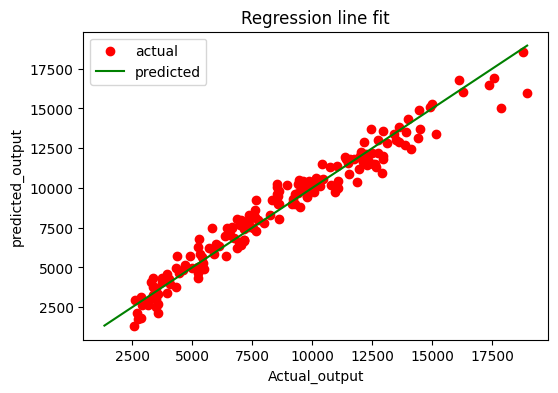

In [47]:
p1=min(min(y_test),min(y_pred))
p2=max(max(y_test),max(y_pred))
plt.figure(figsize=(6,4))
plt.scatter(y_test,y_pred,color='red',label='actual')
plt.plot([p1,p2],[p1,p2],color='green',label='predicted')
plt.legend()
plt.xlabel("Actual_output")
plt.ylabel("predicted_output")
plt.title("Regression line fit")
plt.show()

In [44]:
# quantative measure(MSE,MAE,RMSE,R2_score)
from sklearn.metrics import*
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test,y_pred)
print("mean_squared_error",mse)
print("mean_absolute_error",mae)
print("Root mean squared error",rmse)
print("R2_score",r2_score)

mean_squared_error 635077.1357515425
mean_absolute_error 628.6597689159543
Root mean squared error 796.9172703308309
R2_score 0.9581786735015778


In [46]:
# apply new sample
new_sample=x_test[0:1]
pred=model.predict(new_sample)
print("pedicted charges",pred)

pedicted charges [4359.67120646]


Result:
1.model is multiple linear regression because it has many independent feature and one target column.
    2.From this model charges is predicted